## FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

#### 1.Data Preparation & Exploration

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r'C:\Users\suraj\OneDrive\Desktop\data sets\exchange_rate.csv')
df.columns = ['Date', 'Value']
print(df.head())
print(df.info())

               Date   Value
0  01-01-1990 00:00  0.7855
1  02-01-1990 00:00  0.7818
2  03-01-1990 00:00  0.7867
3  04-01-1990 00:00  0.7860
4  05-01-1990 00:00  0.7849
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    7588 non-null   object 
 1   Value   7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB
None


In [45]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

In [46]:
df = df.dropna(subset=['Date', 'Value'])
df.set_index('Date', inplace=True)

Plot Time Series

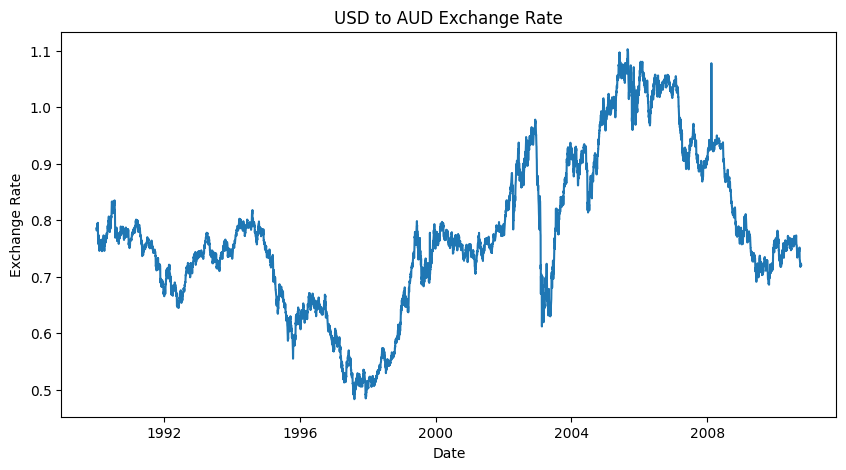

In [47]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0])
plt.title("USD to AUD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

Handle Missing Values

In [48]:

df = df.ffill()

#### Part 2: ARIMA Model

ACF & PACF

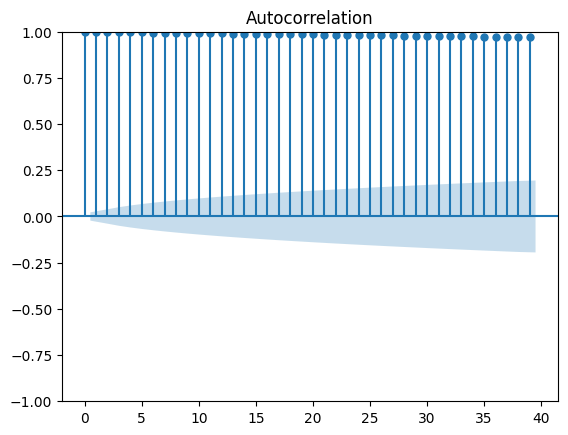

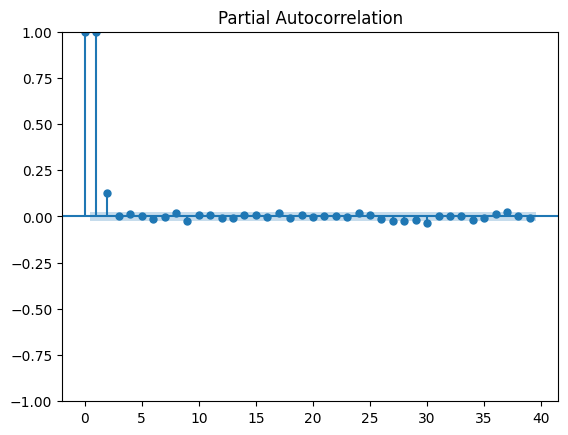

In [59]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df.iloc[:,0])
plot_pacf(df.iloc[:,0])
plt.show()

Fit ARIMA Model

In [60]:
df.iloc[:,0] = pd.to_numeric(df.iloc[:,0], errors='coerce')

In [61]:
print(df.head())
print(df.columns)

             Value
Date              
1990-01-01  0.7855
1990-01-02  0.7818
1990-01-03  0.7867
1990-01-04  0.7860
1990-01-05  0.7849
Index(['Value'], dtype='object')


In [63]:
print(df.columns)   # see all columns

col = df.columns[0]   # select second column (numeric)

df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=[col])

Index(['Value'], dtype='object')


In [65]:
# See data clearly
print(df.head())
print(df.columns)

df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=[col])

print("Final shape:", df.shape)

from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df[col], order=(1,1,1))
print(model.fit().summary())

             Value
Date              
1990-01-01  0.7855
1990-01-02  0.7818
1990-01-03  0.7867
1990-01-04  0.7860
1990-01-05  0.7849
Index(['Value'], dtype='object')
Final shape: (7588, 1)


C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sun, 05 Apr 2026   AIC                         -56102.322
Time:                        15:57:06   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

Diagnostics

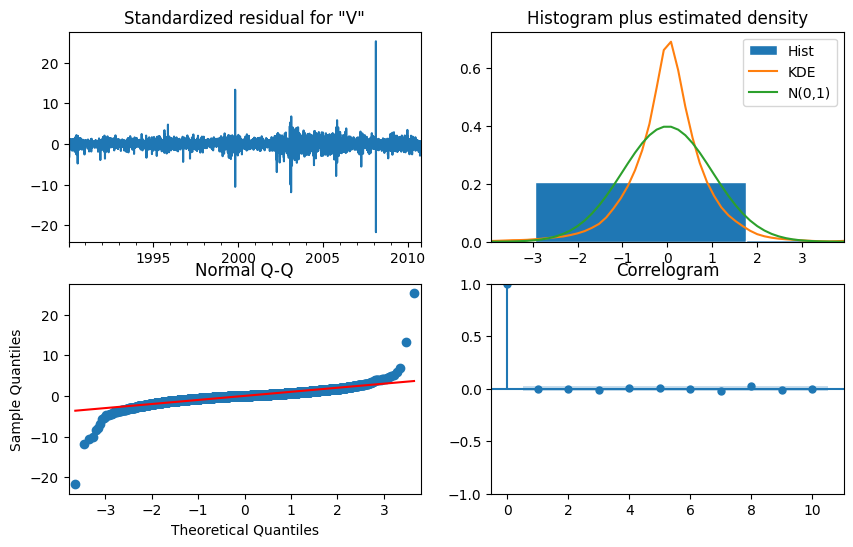

In [74]:
model_arima_fit.plot_diagnostics(figsize=(10,6))
plt.show()

Forecasting

C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


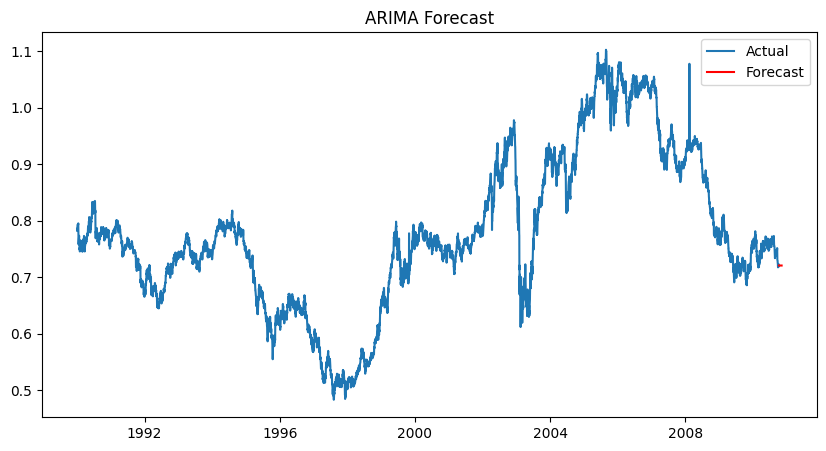

In [69]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Fit model
model_arima = ARIMA(df.iloc[:,0], order=(1,1,1))
model_arima_fit = model_arima.fit()

# Forecast
forecast_arima = model_arima_fit.forecast(steps=30)

# Plot
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0], label='Actual')
plt.plot(forecast_arima, label='Forecast', color='red')

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

#### Part 3: Exponential Smoothing

Fit Holt-Winters Model

In [71]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(
    df.iloc[:,0],
    trend='add',
    seasonal=None
).fit()

forecast_es = model_es.forecast(30)

C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Plot Forecast

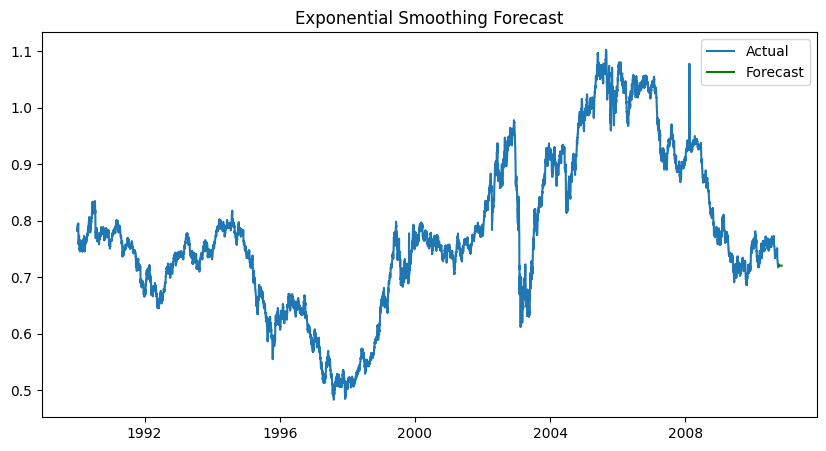

In [72]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0], label='Actual')
plt.plot(forecast_es, label='Forecast', color='green')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

#### Part 4: Evaluation & Comparison

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split data (last 30 for testing)
train = df.iloc[:-30, 0]
test = df.iloc[-30:, 0]

# ARIMA on train
arima_model = ARIMA(train, order=(1,1,1)).fit()
arima_pred = arima_model.forecast(30)

# ES on train
es_model = ExponentialSmoothing(train, trend='add').fit()
es_pred = es_model.forecast(30)

# Metrics
def evaluate(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(abs((actual - pred)/actual)) * 100
    return mae, rmse, mape

print("ARIMA:", evaluate(test, arima_pred))
print("Exponential Smoothing:", evaluate(test, es_pred))

C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\suraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA: (0.013494600805800084, np.float64(0.016632177912815297), np.float64(1.8632207485474443))
Exponential Smoothing: (0.01342316614852778, np.float64(0.01649594250463188), np.float64(1.8531561325102728))


#### Final Explanation 
1 ARIMA:
Captures trend + autocorrelation
Requires parameter tuning (p, d, q)
Works well for stationary data
2Exponential Smoothing:
Simple and fast
Good for trend-based forecasting
Less complex than ARIMA
Comparison:
Model	               Strength	                        Weakness
ARIMA	               Accurate for complex patterns	Needs tuning
Exponential Smoothing  Simple & fast	                Less flexible
